# IND320 – Project work, part 1: Norwegian water reservoirs

**Student:** Iftikhar Amiri
**GitHub repository:** https://github.com/iftikharamiri/ind320
**Streamlit app:** https://ind320-iftikhar-amiri.streamlit.app/
**Screencast:** TODO (link)

## Contents
1. Setup
2. Reading the data
3. Renaming headers to English
4. Inspecting the contents
5. Plotting each column separately
6. Plotting all columns together
7. AI usage
8. Log

## 1. Setup
Libraries used in this notebook, plus a shared colour list and plot style, so all
figures look the same. The colours are a colour-blind-checked categorical palette,
always used in the same order.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Fixed categorical colour order (blue, orange, aqua, yellow, magenta, ...).
# Colour follows the variable, so the same variable has the same colour in every plot.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
           "#008300", "#4a3aa7", "#e34948"]

# Quiet, readable default style for all matplotlib figures in the notebook
plt.rcParams.update({
    "figure.figsize": (11, 3.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})

## 2. Reading the data
`reservoirs.csv` comes from the course repository (`D2Dbook/data`). A copy lives in
this repo's `data/` folder, so the notebook and the Streamlit app read the same file.
The notebook is in `notebooks/`, so the path goes one level up.

In [2]:
DATA_PATH = Path("../data/reservoirs.csv")

raw = pd.read_csv(DATA_PATH)
print(f"{raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

14877 rows x 11 columns


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Renaming headers to English
The original headers are Norwegian abbreviations from NVE (the Norwegian Water
Resources and Energy Directorate). Each row is **one area in one week**.

| Original | English | Meaning |
|---|---|---|
| `dato_Id` | `date` | Date of the weekly measurement |
| `omrType` | `area_type` | `NO` = all of Norway, `EL` = electricity price area, `VASS` = watercourse region |
| `omrnr` | `area_number` | Area number within the type |
| `iso_aar` | `year` | ISO year |
| `iso_uke` | `week` | ISO week number |
| `fyllingsgrad` | `fill_level` | Share of capacity that is filled (0–1) |
| `kapasitet_TWh` | `capacity_TWh` | Total reservoir capacity, as energy |
| `fylling_TWh` | `stored_TWh` | Energy currently stored |
| `neste_Publiseringsdato` | `next_publish_date` | When NVE publishes the next figure |
| `fyllingsgrad_forrige_uke` | `fill_level_prev_week` | Fill level one week earlier |
| `endring_fyllingsgrad` | `fill_level_change` | Change in fill level since last week |

In [3]:
# Mapping from the original Norwegian headers to English names
COLUMN_NAMES = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "year",
    "iso_uke": "week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_TWh",
    "neste_Publiseringsdato": "next_publish_date",
    "fyllingsgrad_forrige_uke": "fill_level_prev_week",
    "endring_fyllingsgrad": "fill_level_change",
}

df = raw.rename(columns=COLUMN_NAMES)

# Parse dates and sort, because the rows in the file are shuffled
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["area_type", "area_number", "date"]).reset_index(drop=True)

# next_publish_date is only publishing metadata; old rows hold the placeholder
# 0001-01-01, so it is dropped from the analysis
df = df.drop(columns="next_publish_date")

# A readable area label, e.g. "NO2" for price area 2 and "Norway" for the total
AREA_LABELS = {"NO": "Norway", "EL": "NO", "VASS": "Watercourse "}
df["area"] = df.apply(
    lambda r: "Norway" if r.area_type == "NO" else f"{AREA_LABELS[r.area_type]}{r.area_number}",
    axis=1,
)
df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_TWh,fill_level_prev_week,fill_level_change,area
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0.734888,-0.113421,NO1
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,0.621467,-0.038367,NO1
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,0.583100,-0.032496,NO1
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,0.550604,-0.042164,NO1
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,0.508440,-0.039217,NO1


## 4. Inspecting the contents
First the data types and missing values, then summary statistics, then how many
weeks each area has.

In [4]:
# Data types and non-null counts (no missing values in any column)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  14877 non-null  datetime64[us]
 1   area_type             14877 non-null  str           
 2   area_number           14877 non-null  int64         
 3   year                  14877 non-null  int64         
 4   week                  14877 non-null  int64         
 5   fill_level            14877 non-null  float64       
 6   capacity_TWh          14877 non-null  float64       
 7   stored_TWh            14877 non-null  float64       
 8   fill_level_prev_week  14877 non-null  float64       
 9   fill_level_change     14877 non-null  float64       
 10  area                  14877 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 1.4 MB


In [5]:
# Summary statistics for the measured quantities
MEASURES = ["fill_level", "capacity_TWh", "stored_TWh",
            "fill_level_prev_week", "fill_level_change"]
df[MEASURES].describe().round(3)

,fill_level,capacity_TWh,stored_TWh,fill_level_prev_week,fill_level_change
count,14877.000,14877.000,14877.000,14877.000,14877.000
mean,0.619,29.146,18.140,0.619,-0.000
std,0.215,22.739,15.966,0.215,0.031
min,0.055,6.003,0.331,0.055,-0.242
25%,0.456,17.391,7.322,0.456,-0.022
50%,0.648,23.238,14.501,0.648,-0.007
75%,0.802,34.044,22.204,0.802,0.016
max,1.020,87.438,84.545,1.020,0.337


In [6]:
# Number of weekly rows and the covered period for each area
df.groupby("area")["date"].agg(weeks="count", first="min", last="max")

,weeks,first,last
area,,,
NO1,1653,1995-01-08,2026-09-06
NO2,1653,1995-01-08,2026-09-06
NO3,1653,1995-01-08,2026-09-06
NO4,1653,1995-01-08,2026-09-06
NO5,1653,1995-01-08,2026-09-06
Norway,1653,1995-01-08,2026-09-06
Watercourse 1,1653,1995-01-08,2026-09-06
Watercourse 2,1653,1995-01-08,2026-09-06
Watercourse 3,1653,1995-01-08,2026-09-06


In [7]:
# The same data in wide form: fill level per area, one column per area.
# This is easier to read than the long format for a quick look.
fill_wide = df.pivot(index="date", columns="area", values="fill_level")
fill_wide.tail().round(3)

area,NO1,NO2,NO3,NO4,NO5,Norway,Watercourse 1,Watercourse 2,Watercourse 3
date,,,,,,,,,
2026-08-09,0.716,0.484,0.604,0.904,0.635,0.641,0.584,0.526,0.817
2026-08-16,0.719,0.481,0.630,0.910,0.653,0.648,0.584,0.538,0.828
2026-08-23,0.713,0.466,0.637,0.908,0.642,0.640,0.571,0.525,0.830
2026-08-30,0.716,0.459,0.627,0.907,0.635,0.634,0.567,0.514,0.828
2026-09-06,0.725,0.461,0.633,0.903,0.639,0.636,0.570,0.517,0.826


## 5. Plotting each column separately
All areas together would give nine overlapping lines per plot, so these plots use the
**Norway total** (`area_type == "NO"`). The columns `year`, `week`, `area_type` and
`area_number` are identifiers, not measurements, so they are not plotted.

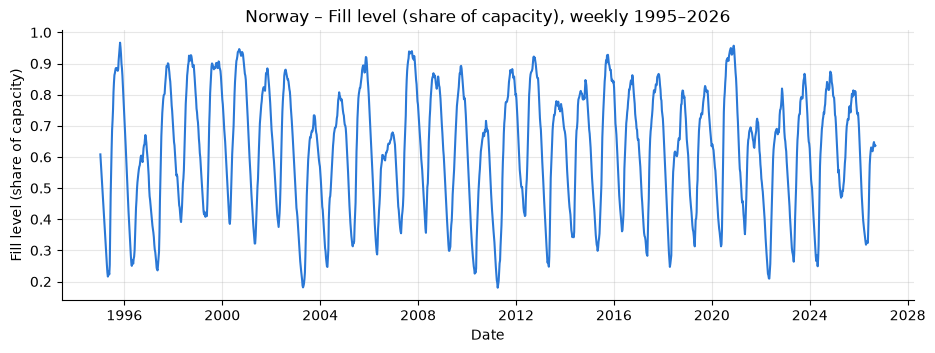

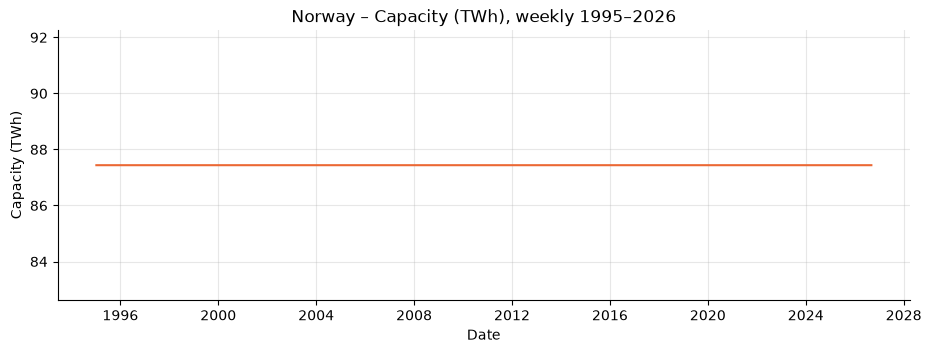

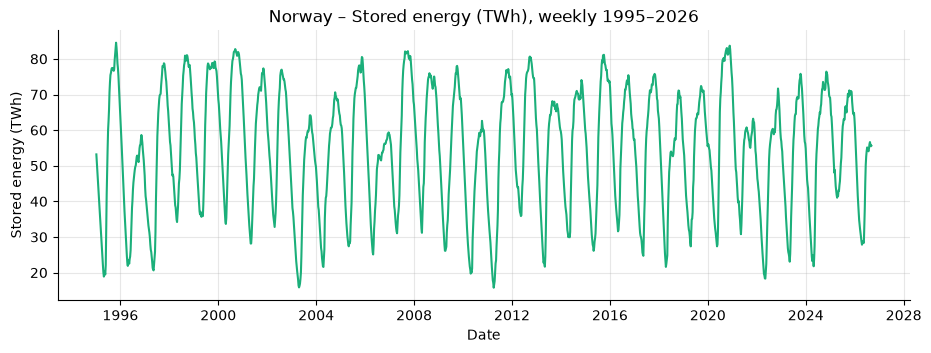

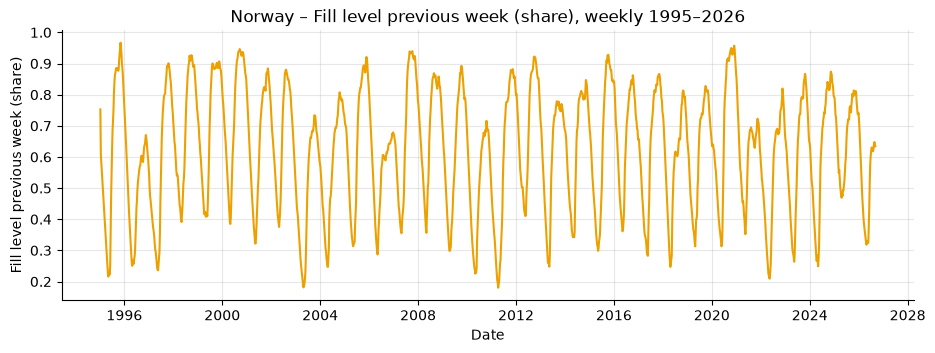

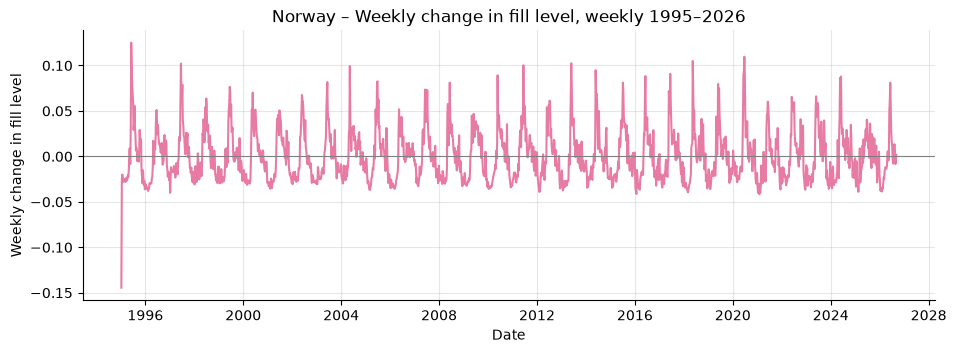

In [8]:
# Weekly series for all of Norway, indexed by date
norway = df[df["area_type"] == "NO"].set_index("date")[MEASURES]

# Axis label and unit for each column
LABELS = {
    "fill_level": "Fill level (share of capacity)",
    "capacity_TWh": "Capacity (TWh)",
    "stored_TWh": "Stored energy (TWh)",
    "fill_level_prev_week": "Fill level previous week (share)",
    "fill_level_change": "Weekly change in fill level",
}

# One figure per column, each with its own colour, title and axis labels
for i, col in enumerate(MEASURES):
    fig, ax = plt.subplots()
    ax.plot(norway.index, norway[col], color=PALETTE[i])
    ax.set_title(f"Norway – {LABELS[col]}, weekly 1995–2026")
    ax.set_xlabel("Date")
    ax.set_ylabel(LABELS[col])
    if col == "fill_level_change":
        ax.axhline(0, color="grey", linewidth=0.8)  # reference line: no change
    plt.show()

**Observations**
- Fill level follows a clear yearly cycle: lowest in April–May before the snow melts,
  highest in September–October.
- Capacity is exactly constant (87.4 TWh for Norway, and one value per area in all
  nine areas). NVE seems to give today's capacity for the whole history, so it is not
  a measurement that changes over time.
- Stored energy has the same shape as fill level because stored = fill level × capacity.
- The weekly change is positive in summer (snowmelt, strongest in June) and negative
  from November to April, when water is used for power production.

## 6. Plotting all columns together
The columns are on very different scales: fill level is 0–1, stored energy goes up to
about 85 TWh, and the weekly change is around ±0.05. On one shared y-axis most lines
would be flat.

I avoided a second y-axis. With two scales the reader can't tell which line belongs
to which axis, and where the lines cross depends only on how each axis was scaled.
I tried two better options instead:

1. **Min–max scaling:** every column is rescaled to 0–1, so all can share one axis.
   This compares the *shape and timing* of the series, not their values.
2. **Small multiples:** one panel per column with a shared time axis, so each keeps
   its real units.

To make the seasonal pattern visible, both use the last three years.

Constant, left out of the scaled plot: ['capacity_TWh']


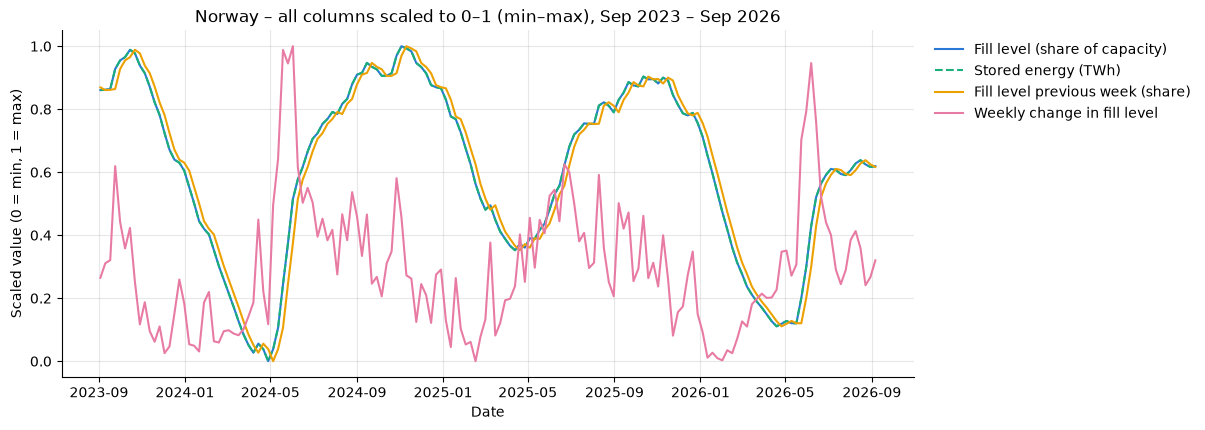

In [9]:
# Last three years for the Norway total
recent = norway.loc["2023-09-01":]

# Min-max scaling: (x - min) / (max - min) puts every column on 0-1.
# A constant column has max == min, which would divide by zero (NaN), so those
# columns are left out of this plot and reported instead.
spread = recent.max() - recent.min()
constant = spread[spread == 0].index.tolist()
print("Constant, left out of the scaled plot:", constant)
scaled = (recent - recent.min()) / spread

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, col in enumerate(MEASURES):
    if col in constant:
        continue
    # Stored energy is drawn dashed: it coincides exactly with fill level once scaled
    style = "--" if col == "stored_TWh" else "-"
    ax.plot(scaled.index, scaled[col], color=PALETTE[i], linestyle=style, label=LABELS[col])
ax.set_title("Norway – all columns scaled to 0–1 (min–max), Sep 2023 – Sep 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Scaled value (0 = min, 1 = max)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
plt.show()

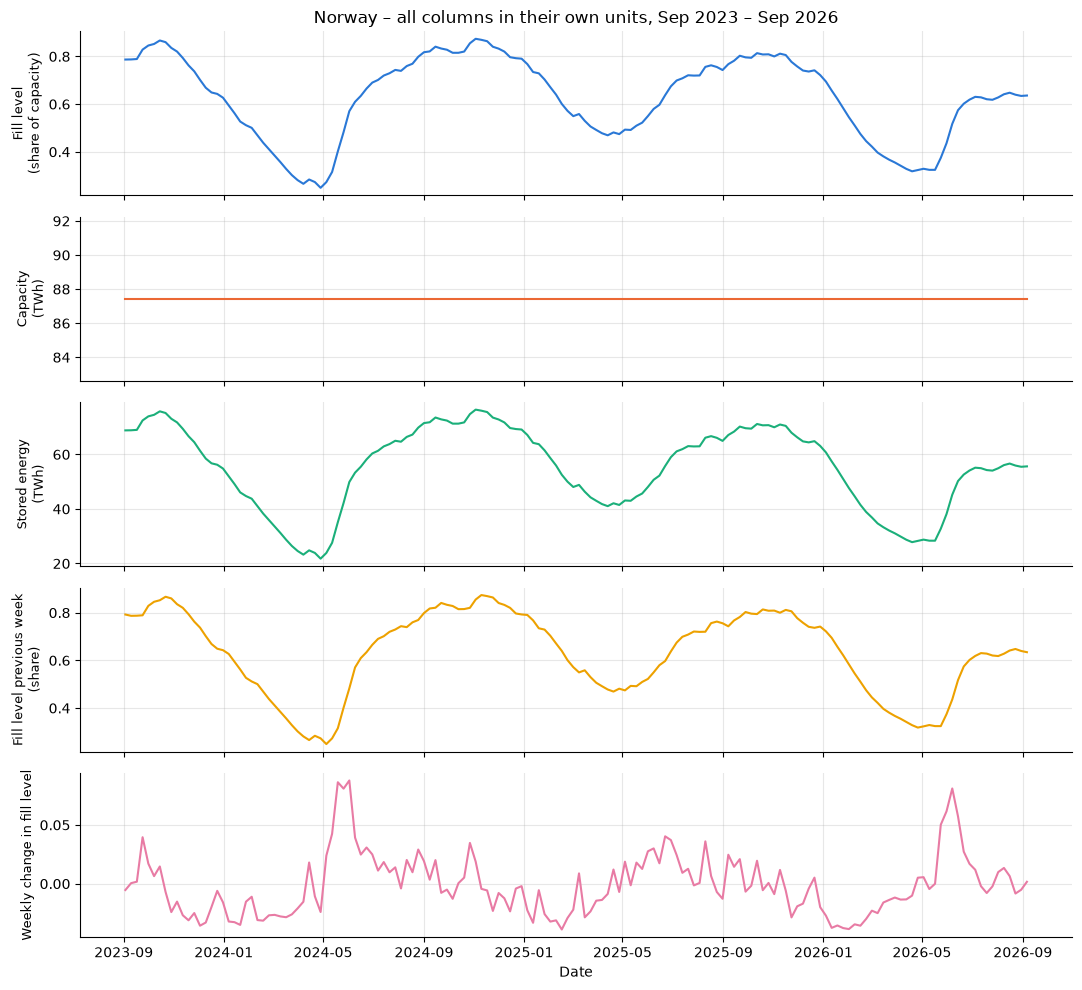

In [10]:
# Small multiples: one panel per column, shared x-axis, each with its own real units
fig, axes = plt.subplots(len(MEASURES), 1, figsize=(11, 10), sharex=True)
for i, (ax, col) in enumerate(zip(axes, MEASURES)):
    ax.plot(recent.index, recent[col], color=PALETTE[i])
    ax.set_ylabel(LABELS[col].replace(" (", "\n("), fontsize=9)
axes[0].set_title("Norway – all columns in their own units, Sep 2023 – Sep 2026")
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

**Observations**
- In the scaled plot, fill level and stored energy are exactly the same line (stored is
  drawn dashed so both show). Capacity is constant, so stored = fill level × a constant,
  and min–max scaling removes the constant.
- Previous-week fill level is the same curve shifted one week to the right.
- Weekly change leads the fill level: it peaks during snowmelt (May–June), while fill
  level keeps rising until about October.
- Capacity can't be min–max scaled at all (max = min), so only the small multiples can
  show it. Min–max scaling also hides the real units, so the small multiples are the
  better choice for reading actual values.

## 7. AI usage
I used Claude Code (Anthropic) as a pair programmer in VS Code during this part:
- **Setup and git:** pulling the latest course repository to get `reservoirs.csv`,
  fixing my `.gitignore`, and moving my work from a side branch back to `main`.
- **Notebook:** suggesting English column names, the plotting code, and how to plot
  columns with very different scales (min–max scaling vs. small multiples). The AI also
  checked the plots against the data, which showed that capacity is constant. Its
  first comment about capacity was wrong and was corrected.
- **Streamlit:** structuring the app (`st.navigation`, one file per page, a shared cached
  loader) and writing the page code. It tested every page with Streamlit's `AppTest`
  before deploying, which caught three bugs.
- **Log:** I wrote the main points, and the AI helped turn them into full text, which I then
  edited.

I read through the code, ran the notebook and the app myself, deployed the app on
Streamlit Community Cloud and checked that it works online.

## 8. Log
GitHub, VS Code, Docker and Streamlit were not completely new to me. I had made a
Streamlit app before as a hobby project, but it was still nice to go through the whole
process again in a more structured way, and I feel that I understand it better now.

In the notebook I read `reservoirs.csv` with pandas. The file contains weekly NVE data
on how full Norwegian hydropower reservoirs are, from 1995 until today, for nine areas:
all of Norway, the five price areas and three watercourse regions. The headers were
Norwegian abbreviations, so I renamed them to English and wrote down what each column
means. The rows in the file were shuffled, so I had to sort them by date before
plotting. When plotting, I learned something about the data itself: the fill level
follows a clear yearly cycle (lowest in April, highest in autumn), and the capacity
column is actually constant. The hardest question was how to plot all columns
together, because fill level is between 0 and 1 while stored energy goes up to about
85 TWh. I compared min–max scaling on one axis with small multiples (one panel per
column). Scaling is good for comparing the shape and timing, but it cannot handle a
constant column and it hides the units. That is why I also used small multiples in the app.

In the Streamlit part I learned the most. I used `st.navigation` for the sidebar menu
with one file per page, and I put the data loading in one shared function with
`st.cache_data`, so the CSV is only read once. That should also make it easy to switch
to MongoDB in part 2, since only that function has to change. New for me were
`LineChartColumn`, which shows a small chart inside a table cell, and `select_slider`
with a range of months. Deploying to Streamlit Community Cloud went smoothly once the
code was on GitHub. I chose Python 3.12 so the cloud runs the same version as my laptop.

I used AI during the whole assignment, and most things were doable and not too
confusing this time. The one thing that went wrong was git: I forgot to switch back to
the `main` branch and tried to push my `.gitignore` changes from another branch. I
also learned that adding a folder to `.gitignore` does not remove files that git
already tracks; you need `git rm --cached` for that.

As an extra, I added a feedback loop to the app. In the sidebar there is a
password-protected form where the teaching assistant can write feedback. The feedback
is saved directly in my GitHub repository and then turned into GitHub issues, so I
can work on each point directly from there.